In [37]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from data_tools import process_data as processed
from data_tools.combine_data import CreateTrainingandTestData
from data_tools import process_dates
from data_tools import handle_datetime
from data_tools import clean_data as clean

combine = CreateTrainingandTestData()
# Change as needed
sensor_id = "Coalinga"
datatype = "o3"
year = "2025"
calibration = "Both"

training_dates = process_dates.training(sensor_id, year, calibration)
testing_dates= process_dates.testing(sensor_id, year, calibration)

# Define files that hold necessary raw data
reference_file_1 = rf"../reference_files/OZONE_PICKDATA_2025-7-29-Fresno.csv"
reference_file_2 = rf"../reference_files/AQLite-2025-11-06.csv"
sensor_file = rf"../reference_files/2025rawdata/{sensor_id}.csv"
precal_reference = handle_datetime.utc_to_CA(processed.ref_data(reference_file_1))
postcal_reference = processed.standard_data(reference_file_2)
postcal_reference = postcal_reference.resample('h').mean()
postcal_reference.index = postcal_reference.index.map(lambda ts: ts.replace(minute=30, second=0, microsecond=0))
postcal_reference = handle_datetime.utc_to_CA(postcal_reference)
voz_data = handle_datetime.utc_to_CA(processed.raw_voz_data(sensor_file))

when = {
    "precal_start": training_dates[0],
    "precal_end": training_dates[1],
    "postcal_start": training_dates[2],
    "postcal_end": training_dates[3],
    "trial1_start": testing_dates[0],
    "trial1_end": testing_dates[1],
    "trial2_start": testing_dates[2],
    "trial2_end": testing_dates[3]
}

combine.set_calibration_parameters(datatype,sensor_id,voz_data)
training_data,all_data = combine.get_combined_data(training_dates,testing_dates,precal_reference,postcal_reference)
training_data, all_data = map(lambda df: clean.eliminate_waste_data_o3(df), [training_data, all_data])

c:\Documents\Senior Year - College\Research\CalibrationCodes\Torrias2025Calibration\voz-data-analysis\data_tools\combine_data.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_training_data = pd.concat([combined, new_rows]).sort_index()


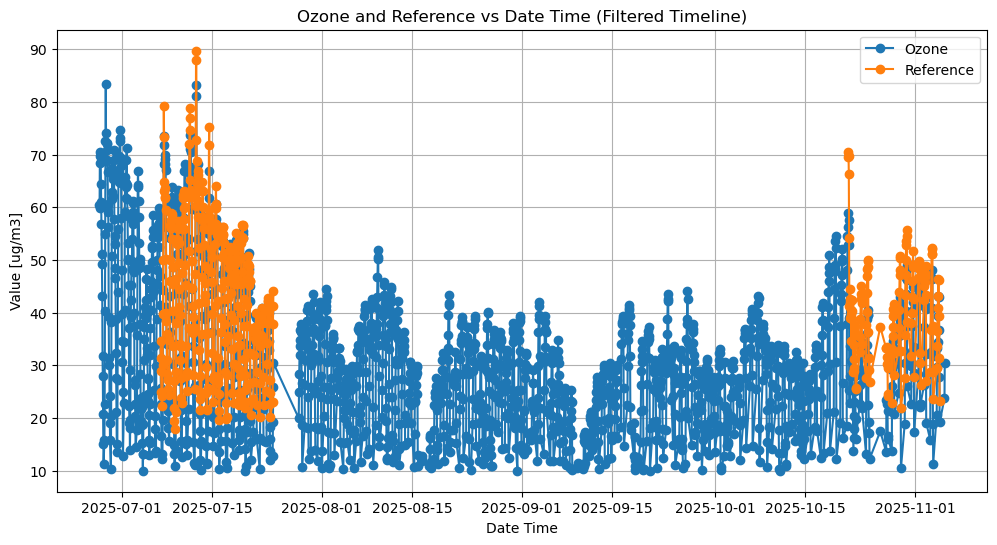

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end dates for the desired timeline
start_date_filter = pd.to_datetime(f"{year}-06-07")
end_date_filter = pd.to_datetime(f"{year}-11-21")

# Apply the date range filter to the merged data
filtered_data = all_data[(all_data.index >= start_date_filter) & (all_data.index <= end_date_filter)]

# Line plot for 'o3' and 'reference' columns against 'date_time' within the specified timeline
plt.figure(figsize=(12, 6))

# Plot 'o3' column
plt.plot(filtered_data.index, filtered_data["o3"], label='Ozone', marker='o')

# Plot 'reference' column
plt.plot(filtered_data.index, filtered_data['reference'], label='Reference', marker='o')

# Customize the plot
plt.title('Ozone and Reference vs Date Time (Filtered Timeline)')
plt.xlabel('Date Time')
plt.ylabel('Value [ug/m3]')
plt.legend()
plt.grid(True)
plt.show()


In [39]:
from data_tools import elastic_net
#elasticnet regression with x variables

variables = ["o3","temp_C","rh","m_PM25_CF1","m_PM10_CF1","week"]
output = rf"../reference_files/2025rawdata/ozone_calibration_variables/{sensor_id}_coefficients.csv"
new_column = "o3_calibrated_prepost"

all_data = all_data.dropna(subset=variables)
training_data = training_data.dropna(subset=variables + ['reference'])
try:
    calibration_model = elastic_net.calibrate(training_data, variables, output)
    calibrated_data = elastic_net.apply_calibration(calibration_model,all_data,variables,new_column)
    print("Calibrated data:", calibrated_data[new_column])
except ValueError as e:
    print("Error:", e)



No data in range '10 and under', skipping...
Range '10+' | Coefficients: [0.78508577 0.34068372 0.12211151 0.03139541 0.1261163  0.26375145] | Intercept: -11.040460794598324
Calibration coefficients saved to ../reference_files/2025rawdata/ozone_calibration_variables/Coalinga_coefficients.csv
No trained model for range '10 and under', skipping...
Applied calibration models; results stored in 'o3_calibrated_prepost'
Calibrated data: date_time
2025-06-27 12:30:00    51.460471
2025-06-27 13:30:00    58.619914
2025-06-27 14:30:00    65.698766
2025-06-27 15:30:00    67.139016
2025-06-27 16:30:00    66.513787
                         ...    
2025-11-04 17:30:00    40.698454
2025-11-04 18:30:00    33.599249
2025-11-04 19:30:00    26.696406
2025-11-05 13:30:00    33.153911
2025-11-05 14:30:00    38.355988
Name: o3_calibrated_prepost, Length: 1887, dtype: float64


In [40]:
calibrated_file = rf"../reference_files/{year}OzoneDataCalibrated/{sensor_id}_calibrated.csv"
calibrated_data.to_csv(calibrated_file, index=True)

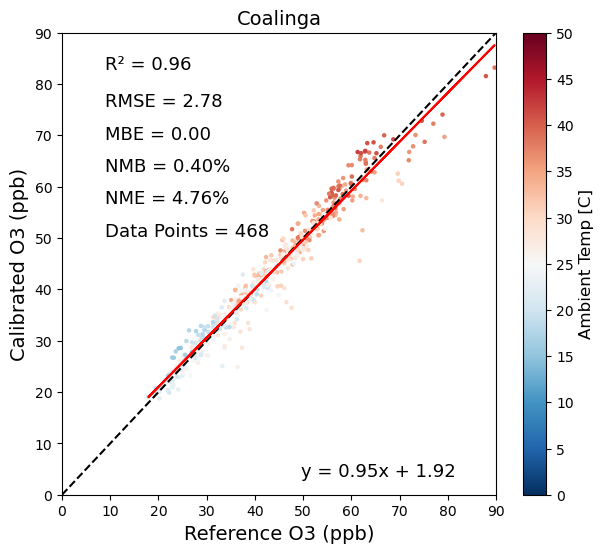

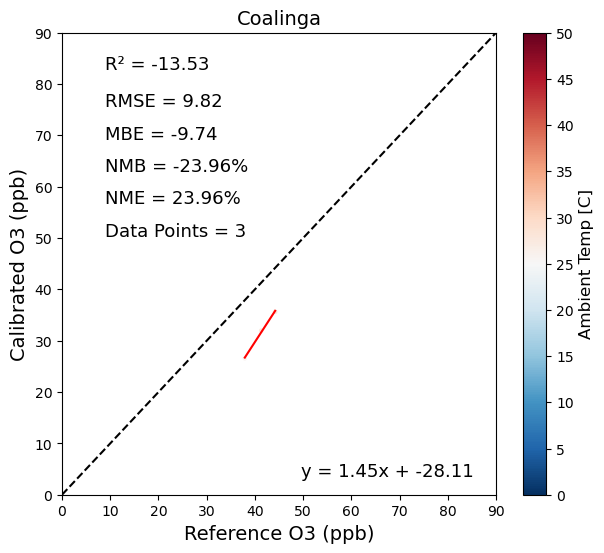

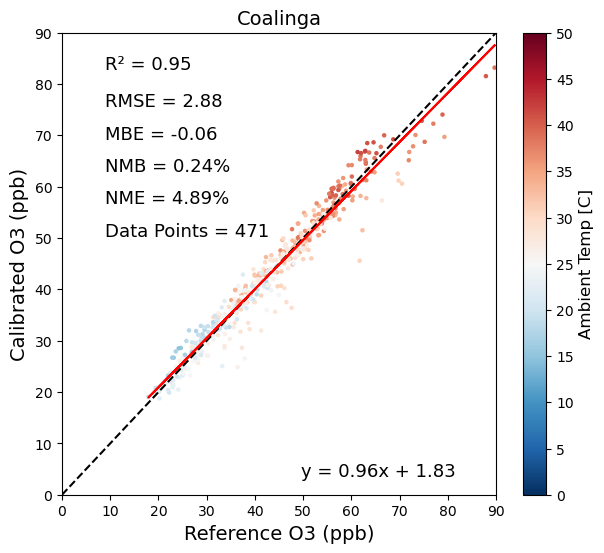

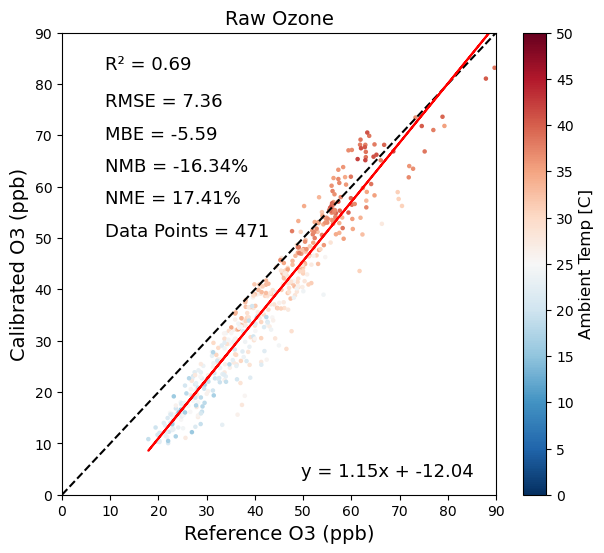

In [41]:
from data_tools.plot_against_reference import PlotOzone
po = PlotOzone()

calibrated_data = calibrated_data.dropna(subset=['reference'])

training_data = combine.subsection(calibrated_data,training_dates)
testing_data = combine.subsection(calibrated_data,testing_dates)

po.plot(training_data,sensor_id,"Training",calibration)
po.plot(testing_data,sensor_id,"Testing",calibration)
po.plot(calibrated_data,sensor_id,"All",calibration)

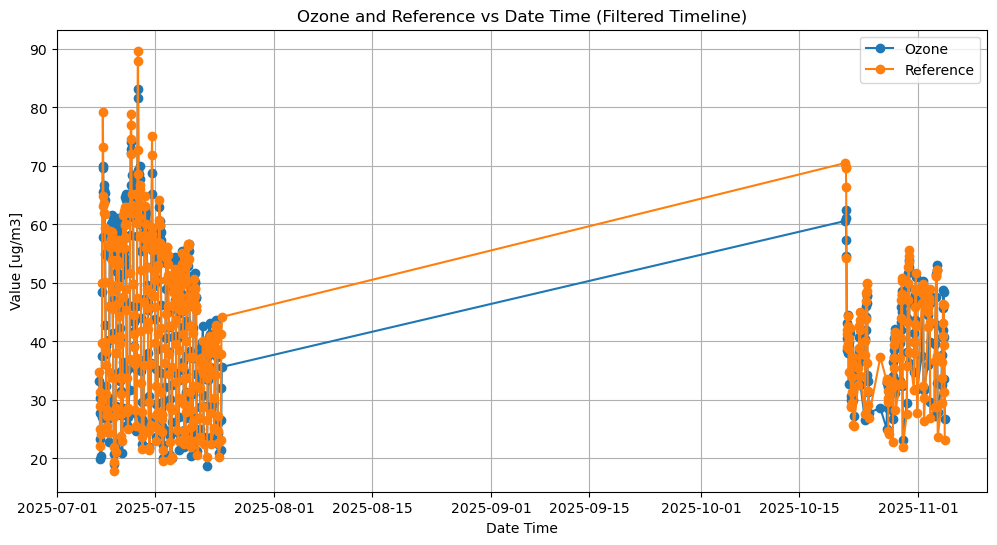

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end dates for the desired timeline
start_date_filter = pd.to_datetime(f"{year}-06-07")
end_date_filter = pd.to_datetime(f"{year}-11-21")

# Apply the date range filter to the merged data
filtered_data = calibrated_data[(calibrated_data.index >= start_date_filter) & (calibrated_data.index <= end_date_filter)]

# Line plot for 'o3' and 'reference' columns against 'date_time' within the specified timeline
plt.figure(figsize=(12, 6))

# Plot 'o3' column
plt.plot(filtered_data.index, filtered_data["o3_calibrated_prepost"], label='Ozone', marker='o')

# Plot 'reference' column
plt.plot(filtered_data.index, filtered_data['reference'], label='Reference', marker='o')

# Customize the plot
plt.title('Ozone and Reference vs Date Time (Filtered Timeline)')
plt.xlabel('Date Time')
plt.ylabel('Value [ug/m3]')
plt.legend()
plt.grid(True)
plt.show()
